In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, QuantileTransformer
import os

In [3]:
output_folder = "../../bats_transformer/outputs/july_daytime_new_mask_11_5"

In [4]:
scaler_path = "../../bats_transformer/data/july_daytime_chunked_quantile/splits/split_scaler.pkl"
import joblib
scaler = joblib.load(open(f'{scaler_path}', 'rb'))
non_scaler_columns = {}

def unscale(df):
    temp_df = df.copy()
    for idx, column in enumerate(temp_df.columns):
        if column not in scaler.feature_names_in_:
            non_scaler_columns[idx] = temp_df[column]
            temp_df.drop(columns=[column], inplace=True)

    all_features = list(scaler.feature_names_in_)
    column_idxs = [] # indices of columns in predictions that are in scaler.feature_names_in_
    for column in scaler.feature_names_in_:
        if column not in temp_df.columns:
            temp_df[column] = 0
        else:
            column_idxs.append(all_features.index(column))

    temp_df = temp_df[scaler.feature_names_in_]

    df_np = temp_df.to_numpy()
    df_np = df_np[:, :-1]

    inverted_predictions = scaler.inverse_transform(temp_df)

    filtered_inverted_predictions = inverted_predictions[:, column_idxs]

    original_df = pd.DataFrame(filtered_inverted_predictions, columns=[temp_df.columns[i] for i in column_idxs])
    return original_df

/home/ayc227/miniconda3/envs/bats/lib/python3.8/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator QuantileTransformer from version 1.3.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
# get all files (not directories) in output_folder
if not os.path.exists(output_folder):
    raise FileNotFoundError(f"output_folder does not exist: {output_folder}")

prediction_files = [
    os.path.join(output_folder, fn)
    for fn in sorted(os.listdir(output_folder))
    if os.path.isfile(os.path.join(output_folder, fn)) and fn.endswith("predictions.log")
]

truth_files = [
    os.path.join(output_folder, fn)
    for fn in sorted(os.listdir(output_folder))
    if os.path.isfile(os.path.join(output_folder, fn)) and fn.endswith("ground_truths.log")
]

print(f"Found {len(prediction_files)} files in {output_folder}")

Found 10 files in ../../bats_transformer/outputs/july_daytime_new_mask_11_5


In [6]:
absolute_errors = []
euclidean_distances = []
for pred_file, truth_file in zip(prediction_files, truth_files):
    pred_df = pd.read_csv(pred_file)
    truth_df = pd.read_csv(truth_file)

    # select numeric columns and keep only common columns
    pred_num = pred_df.select_dtypes(include=[np.number])
    truth_num = truth_df.select_dtypes(include=[np.number])
    common_cols = pred_num.columns.intersection(truth_num.columns)

    if len(common_cols) == 0:
        # nothing numeric in common, append empty dataframe
        absolute_errors.append(pd.DataFrame())
    else:
        # align row counts (use the shorter one) and reset index for safe subtraction
        n = min(len(pred_num), len(truth_num))
        pred_slice = pred_num.loc[: n - 1, common_cols].reset_index(drop=True)
        truth_slice = truth_num.loc[: n - 1, common_cols].reset_index(drop=True)

        # error = truth - prediction, keep absolute per-cell errors
        errors = truth_slice - pred_slice
        abs_errors = errors.abs()

        euclidean_distances.append((errors * errors).sum(axis=1).pow(0.5))

        absolute_errors.append(abs_errors)

In [7]:
euclidean_distances = np.array(euclidean_distances)

In [8]:
euclidean_distances

array([[5.11285857, 6.72115233, 4.6237455 , ..., 6.16710375, 3.4374748 ,
        9.36463878],
       [4.83647984, 6.65012077, 4.79342284, ..., 6.20111758, 3.03794094,
        9.22359231],
       [5.16004874, 6.8367    , 4.63370004, ..., 6.11764459, 3.38771128,
        9.44091811],
       ...,
       [5.23442769, 6.98309591, 4.57311084, ..., 6.51775095, 3.43776953,
        9.19930335],
       [4.25099356, 6.81614387, 4.76025912, ..., 6.77227832, 3.37256765,
        9.19980953],
       [4.55254961, 6.65335749, 4.32187381, ..., 6.51495408, 3.12030241,
        8.85180709]])

In [9]:
for error_df in absolute_errors:
    error_df.drop(["Unnamed: 0", "TimeIndex", "file_id", "chirp_idx"], axis=1, inplace=True, errors="ignore")

In [10]:
absolute_errors[0]

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Bndw32dB,Amp1stQrtl,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start
0,0.129632,0.197680,0.592784,1.036941,0.647368,0.518081,0.232533,0.310658,0.558254,0.063608,...,1.344746,0.806858,0.067478,0.528592,1.049203,0.700694,0.673351,0.581029,0.602546,0.453783
1,0.359796,0.546163,0.606684,0.452673,0.441363,0.390311,1.922336,3.001420,0.683413,0.425171,...,0.374907,0.229301,1.090259,1.211925,1.062946,1.146820,0.588652,0.788506,0.280210,0.841790
2,0.182353,0.592670,0.461039,0.170124,1.112749,0.398978,1.051340,0.848939,0.557553,0.702413,...,0.031903,0.797004,0.438044,0.775359,0.710586,0.620523,0.880335,0.371923,0.793722,0.746202
3,0.469903,1.151065,0.957272,1.082002,0.781367,0.000296,1.332856,0.439318,0.973867,0.722651,...,0.495274,0.006042,0.380689,0.873325,0.872587,0.703363,0.570715,2.369965,2.174021,0.631012
4,0.084090,0.763561,1.033261,1.329104,0.509939,0.250706,1.220403,0.275308,1.140567,0.522255,...,1.650280,0.447623,0.051155,0.428508,0.113695,0.966136,1.197406,0.902420,0.980447,0.507412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,0.214996,1.312814,1.752299,2.047373,0.307701,1.602562,0.555566,0.638248,1.973254,1.358404,...,1.645778,1.801796,1.418174,0.253504,1.084635,1.436125,1.399165,1.524863,1.087156,0.412191
1378,0.345910,1.157687,1.443115,1.069781,0.417157,0.469497,0.637211,0.271167,1.462656,1.587524,...,0.661674,1.842842,2.236593,1.952731,0.927106,0.315832,0.295340,0.613664,0.606258,0.459991
1379,0.173373,0.684761,0.737784,1.077089,0.119293,0.412660,0.387021,1.569078,0.597424,0.794339,...,1.524487,0.311210,0.870914,0.475207,0.913820,0.080731,1.413329,0.418435,1.170145,1.664562
1380,0.293840,1.102733,0.220775,0.066811,0.354275,0.229286,0.152552,0.853370,0.117522,0.076179,...,0.504315,0.300384,0.268249,0.583475,0.021922,0.479270,0.526208,0.203688,0.414821,0.735602


In [11]:
average_error_per_point = []
for error_df in absolute_errors:
    if not error_df.empty:
        avg_error = error_df.mean(axis=1)
        average_error_per_point.append(avg_error.values)
    else:
        average_error_per_point.append(np.nan)  # or some other placeholder for empty dataframes
average_error_per_point = np.array(average_error_per_point)
average_error_per_point

array([[0.62769184, 0.78845491, 0.66733832, ..., 0.85890557, 0.40670611,
        1.20991445],
       [0.59637429, 0.78899771, 0.7159202 , ..., 0.85313024, 0.39361721,
        1.21425757],
       [0.63639983, 0.7923202 , 0.67866269, ..., 0.8391688 , 0.44123859,
        1.23849951],
       ...,
       [0.64321042, 0.79425226, 0.68329352, ..., 0.8953314 , 0.42826058,
        1.164746  ],
       [0.5688045 , 0.83742604, 0.64746897, ..., 0.92096753, 0.43819495,
        1.17629248],
       [0.56967804, 0.79730924, 0.60757134, ..., 0.91903331, 0.42715741,
        1.16201789]])

In [12]:
def _read_log_to_df(path):
    try:
        # let pandas try to infer delimiter
        return pd.read_csv(path, sep=None, engine="python")
    except Exception:
        try:
            # fallback to generic table reader
            return pd.read_table(path, engine="python")
        except Exception:
            # final fallback: one line per row
            with open(path, "r", encoding="utf-8", errors="ignore") as f:
                lines = [ln.rstrip("\n") for ln in f]
            return pd.DataFrame({"line": lines})

# read all .log files into a list of DataFrames
df_list = [_read_log_to_df(p) for p in prediction_files]
truth_list = [_read_log_to_df(p) for p in truth_files]

In [13]:
def cluster_predictions(predictions, index):
    preds_i = np.array([pred.iloc[index] for pred in predictions])
    return preds_i

pred_cluster_0 = cluster_predictions(df_list, 0)
pred_cluster_0[:, 2:len(pred_cluster_0[0]) - 3]

array([[0.8736584, -0.15249985, 0.84529996, 0.78250194, 0.4162272,
        -0.3497133, 0.6913856, -0.3630016, 0.92452884, 0.4365597,
        0.3543175, 0.36537018, 0.29564568, -2.4546363, 0.046010494,
        -0.018134378, 0.4517412, 0.18194768, 0.47397503, 0.41261387,
        0.32317775, 0.12863046, -0.111735225, -0.5258467, -0.16901164,
        -0.118196115, -0.5073325, 0.50629044, 0.6361921, 0.36283287,
        0.31257585, -0.30527633],
       [1.1036644, -0.13447498, 0.9103319, 0.8574595, 0.37039283,
        -0.38978583, 0.4931864, -0.39128864, 1.0335901, 0.56136,
        0.48170507, 0.32891068, 0.3031165, -2.1524396, 0.160209,
        0.07596026, 0.565254, 0.16041984, 0.40548742, 0.39083114,
        0.4489602, 0.20621176, -0.18589412, -0.37252423, -0.31187585,
        -0.15051566, -0.52240217, 0.5695948, 0.57085276, 0.39893216,
        0.3373074, -0.33172128],
       [0.7172572, -0.06801555, 0.8070659, 0.7725672, 0.37932795,
        -0.17722249, 0.5103225, -0.39105725, 0.8964933, 

In [14]:
from scipy import special
from scipy.spatial.distance import pdist

def compute_cluster_measures(X, radius_for_density=None):
    """
    Compute cluster measures for an array X of shape (n_points, n_features).
    Returns a dict with:
      - n, dim
      - centroid
      - distances (to centroid)
      - radius (max distance to centroid)
      - avg_radius (mean distance to centroid)
      - std_radius
      - diameter (max pairwise distance)
      - avg_pairwise_distance
      - tightness = 1 / (1 + avg_pairwise_distance)  (higher -> tighter)
      - density = n_points / vol_ball(radius)  (uses 'radius' or radius_for_density if provided)
    """
    X = X[:, 2:len(pred_cluster_0[0]) - 3]
    X = np.asarray(X, dtype=float)
    
    if X.ndim != 2:
        raise ValueError("X must be 2D (n_points, n_features)")
    n, d = X.shape

    centroid = X.mean(axis=0)
    distances = np.linalg.norm(X - centroid, axis=1)
    radius = float(distances.max()) if n > 0 else 0.0
    avg_radius = float(distances.mean()) if n > 0 else 0.0
    std_radius = float(distances.std(ddof=0)) if n > 0 else 0.0

    if n > 1:
        pairwise = pdist(X, metric="euclidean")
        diameter = float(pairwise.max())
        avg_pairwise = float(pairwise.mean())
    else:
        pairwise = np.array([])
        diameter = 0.0
        avg_pairwise = 0.0

    # tightness: inverse of typical pairwise distance (bounded)
    tightness = 1.0 / (1.0 + avg_pairwise) if avg_pairwise >= 0 else np.nan

    # density: n / volume_of_d_ball(radius)
    r = radius_for_density if (radius_for_density is not None) else radius
    if r <= 0:
        density = np.inf if n > 0 else 0.0
    else:
        # Volume of d-dimensional ball: V_d(r) = pi^(d/2) / Gamma(d/2 + 1) * r^d
        vol_unit_ball = (np.pi ** (d / 2.0)) / special.gamma(d / 2.0 + 1.0)
        vol = vol_unit_ball * (r ** d)
        density = n / vol if vol > 0 else np.inf

    return {
        "n_points": n,
        "dim": d,
        "centroid": centroid,
        "distances_to_centroid": distances,
        "radius_max": radius,
        "radius_mean": avg_radius,
        "radius_std": std_radius,
        "diameter_pairwise": diameter,
        "avg_pairwise_distance": avg_pairwise,
        "tightness": tightness,
        "density": density,
    }

# Example: compute measures for pred_cluster_0 (assumes pred_cluster_0 exists in the notebook)
measures_pred_cluster_0 = compute_cluster_measures(pred_cluster_0)
for k, v in measures_pred_cluster_0.items():
    if k == "centroid":
        print(f"{k}: array(shape={v.shape})")
    elif k == "distances_to_centroid":
        print(f"{k}: {v}")
    else:
        print(f"{k}: {v}")

n_points: 10
dim: 32
centroid: array(shape=(32,))
distances_to_centroid: [0.43573419 0.41541848 0.6259194  0.56229339 0.66812709 0.47582362
 0.57111076 0.63928775 1.053218   0.55993182]
radius_max: 1.0532180038832903
radius_mean: 0.6006864510510078
radius_std: 0.17105370191194288
diameter_pairwise: 1.497399888874357
avg_pairwise_distance: 0.8980369110410737
tightness: 0.5268601438585827
density: 442218.4417226359


In [15]:
error_cluster = cluster_predictions(absolute_errors, 0)

In [16]:
tightness = []
radii = []
densities = []
error_densities = []
for i in range(len(df_list[0])):
    pred_cluster_i = cluster_predictions(df_list, i)
    measures = compute_cluster_measures(pred_cluster_i)
    tightness.append(measures["tightness"])
    radii.append(measures["radius_mean"])
    densities.append(measures["density"])

    error_cluster_i = cluster_predictions(absolute_errors, i)
    error_measures = compute_cluster_measures(error_cluster_i)
    error_densities.append(error_measures["density"])
    # print(measures["tightness"])
df_tightness = df_list[0][['file_id', 'chirp_idx']].copy()
df_tightness.insert(0, 'id', df_list[0].index)
df_tightness['tightness'] = tightness
df_tightness['radius_mean'] = radii
df_tightness['density'] = densities
df_tightness['average_error_per_point'] = average_error_per_point.mean(axis=0)
df_tightness['error_density'] = error_densities
df_tightness['euclidean_distance'] = euclidean_distances.mean(axis=0)
df_tightness

,id,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance
0,0,4951.0,12.0,0.526860,0.600686,4.422184e+05,0.599231,5.942154e+05,4.905527
1,1,4951.0,11.0,0.522362,0.615319,8.956186e+06,0.821912,2.623837e+07,6.864975
2,2,4951.0,10.0,0.536329,0.579338,3.965895e+08,0.649368,7.130131e+09,4.536180
3,3,4951.0,9.0,0.549180,0.548896,9.112192e+08,1.143015,4.618573e+08,8.161767
4,4,4951.0,8.0,0.527006,0.603052,4.857583e+08,0.908176,2.991323e+09,6.296044
...,...,...,...,...,...,...,...,...,...
1377,1377,5186.0,10.0,0.546133,0.559814,2.503041e+09,1.132841,5.795104e+08,7.356445
1378,1378,5186.0,9.0,0.534472,0.579363,5.284009e+05,0.967602,9.949941e+05,6.702022
1379,1379,5186.0,8.0,0.540029,0.564223,3.299655e+07,0.884018,2.082419e+07,6.376911
1380,1380,5186.0,7.0,0.521615,0.613598,5.284152e+07,0.425495,8.271680e+07,3.332559


0.3619558552188079 0.4742450776889467 0.5178916522233212 0.5725514016700443 0.9375851027171486


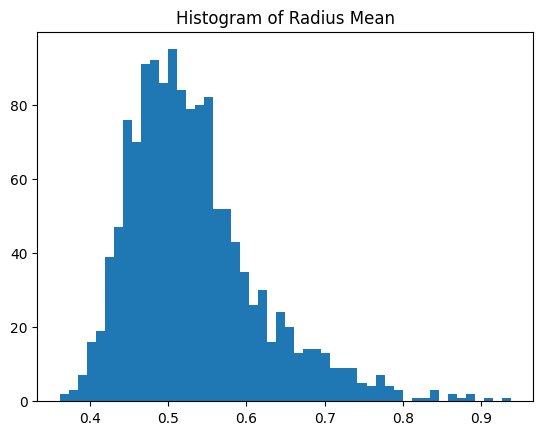

In [20]:
plt.hist(df_tightness['radius_mean'], bins=50)
print(np.percentile(df_tightness['radius_mean'], 0), np.percentile(df_tightness['radius_mean'], 25), np.percentile(df_tightness['radius_mean'], 50), np.percentile(df_tightness['radius_mean'], 75), np.percentile(df_tightness['radius_mean'], 100))
plt.title('Histogram of Radius Mean');

In [18]:
low_confidence_threshold = np.percentile(df_tightness['radius_mean'], 90)
low_confidence_threshold

0.6480111869765535

In [22]:
df_tightness["low_confidence"] = df_tightness['radius_mean'] >= low_confidence_threshold
df_tightness

,id,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence
0,0,4951.0,12.0,0.526860,0.600686,4.422184e+05,0.599231,5.942154e+05,4.905527,False
1,1,4951.0,11.0,0.522362,0.615319,8.956186e+06,0.821912,2.623837e+07,6.864975,False
2,2,4951.0,10.0,0.536329,0.579338,3.965895e+08,0.649368,7.130131e+09,4.536180,False
3,3,4951.0,9.0,0.549180,0.548896,9.112192e+08,1.143015,4.618573e+08,8.161767,False
4,4,4951.0,8.0,0.527006,0.603052,4.857583e+08,0.908176,2.991323e+09,6.296044,False
...,...,...,...,...,...,...,...,...,...,...
1377,1377,5186.0,10.0,0.546133,0.559814,2.503041e+09,1.132841,5.795104e+08,7.356445,False
1378,1378,5186.0,9.0,0.534472,0.579363,5.284009e+05,0.967602,9.949941e+05,6.702022,False
1379,1379,5186.0,8.0,0.540029,0.564223,3.299655e+07,0.884018,2.082419e+07,6.376911,False
1380,1380,5186.0,7.0,0.521615,0.613598,5.284152e+07,0.425495,8.271680e+07,3.332559,False


In [23]:
df_list[0]

,Unnamed: 0,TimeIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,model_id
0,0,13.0,0.873658,-0.152500,0.845300,0.782502,0.416227,-0.349713,0.691386,-0.363002,...,-0.118196,-0.507332,0.506290,0.636192,0.362833,0.312576,-0.305276,4951.0,12.0,models/july_daytime_new_mask_11_5/model_31
1,1,12.0,0.479325,-0.099467,0.867443,0.986544,0.448127,-0.304522,0.619461,-0.488405,...,-0.196181,-0.486954,0.713239,0.671715,0.504394,0.440192,-0.329307,4951.0,11.0,models/july_daytime_new_mask_11_5/model_31
2,2,11.0,0.575651,-0.127266,1.046360,1.036543,0.333235,-0.275729,0.710088,-0.410816,...,-0.113184,-0.482858,0.715314,0.651343,0.605285,0.272196,-0.258845,4951.0,10.0,models/july_daytime_new_mask_11_5/model_31
3,3,10.0,0.137561,-0.106656,0.897514,0.908068,0.306739,-0.332275,0.339558,-0.445230,...,-0.132048,-0.428347,0.494226,0.534702,0.221026,0.173408,-0.204925,4951.0,9.0,models/july_daytime_new_mask_11_5/model_31
4,4,9.0,0.209896,-0.102400,0.873664,0.688725,0.230770,-0.271251,0.332268,-0.435324,...,-0.097215,-0.293999,0.497240,0.370400,0.048351,-0.033229,-0.148444,4951.0,8.0,models/july_daytime_new_mask_11_5/model_31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,1377,11.0,1.314562,0.030472,0.585310,0.354572,0.216357,-0.048298,0.354309,-0.158906,...,-0.115706,0.115777,0.133234,0.186265,0.249969,-0.075790,-0.070138,5186.0,10.0,models/july_daytime_new_mask_11_5/model_31
1378,1378,10.0,0.623517,0.055063,0.777969,0.481153,0.374128,0.125286,0.395969,-0.083162,...,-0.317540,-0.062802,0.303252,0.166478,0.221854,0.042222,-0.120078,5186.0,9.0,models/july_daytime_new_mask_11_5/model_31
1379,1379,9.0,0.435600,-0.000002,0.968898,0.695507,0.317433,0.249776,0.400585,-0.106710,...,-0.286039,-0.064577,0.273657,0.377982,0.373841,0.138382,-0.056181,5186.0,8.0,models/july_daytime_new_mask_11_5/model_31
1380,1380,8.0,0.094591,-0.238368,0.937497,0.759898,0.260255,0.378735,0.369492,-0.165009,...,-0.333025,-0.058976,0.246588,0.330741,0.343837,0.116454,0.057460,5186.0,7.0,models/july_daytime_new_mask_11_5/model_31


In [17]:
truth_list[0]

,Unnamed: 0,TimeIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,model_id
0,0,13.0,1.003290,0.045180,1.438084,1.819443,1.063595,-0.867794,0.458852,-0.052344,...,-0.646788,-1.556536,1.206985,1.309543,0.943862,0.915122,-0.759059,4951.0,12.0,models/july_daytime_new_mask_11_5/model_31
1,1,12.0,0.839121,-0.645631,0.260759,0.533871,0.006765,0.085789,-1.302875,2.513015,...,1.015744,-1.549900,-0.433581,0.083062,-0.284112,0.159982,0.512483,4951.0,11.0,models/july_daytime_new_mask_11_5/model_31
2,2,11.0,0.758004,0.465405,1.507399,1.206667,1.445984,-0.674706,1.761428,-1.259755,...,-0.888544,0.227728,1.335838,1.531678,0.977207,1.065919,-1.005047,4951.0,10.0,models/july_daytime_new_mask_11_5/model_31
3,3,10.0,0.607463,1.044409,1.854786,1.990070,1.088106,-0.331979,1.672414,-0.884548,...,0.741277,0.444240,1.197589,1.105417,2.590991,2.347429,-0.835938,4951.0,9.0,models/july_daytime_new_mask_11_5/model_31
4,4,9.0,0.293986,0.661162,1.906924,2.017829,0.740709,-0.020545,1.552670,-0.710632,...,0.331293,-0.407695,1.463375,1.567807,0.950771,0.947218,-0.655856,4951.0,8.0,models/july_daytime_new_mask_11_5/model_31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,1377,11.0,1.529558,1.343287,-1.166990,-1.692801,0.524058,-1.650859,-0.201257,-0.797153,...,0.137798,-0.968858,-1.302892,-1.212901,-1.274895,-1.162946,-0.482329,5186.0,10.0,models/july_daytime_new_mask_11_5/model_31
1378,1378,10.0,0.969427,1.212751,-0.665146,-0.588627,-0.043029,-0.344211,-0.241242,0.188005,...,1.635191,0.864305,0.619084,0.461818,0.835518,0.648480,0.339913,5186.0,9.0,models/july_daytime_new_mask_11_5/model_31
1379,1379,9.0,0.608973,-0.684763,0.231114,-0.381582,0.436725,-0.162884,0.787606,-1.675788,...,0.189168,0.849243,0.354388,-1.035346,-0.044595,-1.031763,-1.720743,5186.0,8.0,models/july_daytime_new_mask_11_5/model_31
1380,1380,8.0,0.388430,0.864365,1.158272,0.826709,0.614529,0.149449,0.216940,0.688360,...,0.250450,-0.037054,0.725857,0.856949,0.547525,0.531275,-0.678142,5186.0,7.0,models/july_daytime_new_mask_11_5/model_31


In [18]:
unscaled_df_0 = unscale(df_list[0])
unscaled_df_0

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Bndw32dB,Amp1stQrtl,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start
0,811.038996,39.000000,58.900062,30.383310,35.013138,61.054414,43.013958,35.183904,59.521374,46.469902,...,25.769666,66.526436,10071.861784,14311.310625,10090.320494,11.491760,11.106958,99.673216,104.795046,7.658386
1,681.537116,41.000000,59.138214,32.220818,35.190590,61.990851,42.528935,33.300654,59.813268,45.845239,...,25.260172,66.916623,10097.892099,13922.002271,10194.378532,13.038612,11.313148,108.771703,111.763265,7.487895
2,713.856807,40.000000,61.058428,32.737606,34.557549,62.546399,43.135030,34.496788,60.176410,46.451418,...,25.699663,67.997045,10950.808674,14336.062616,10212.109035,13.057829,11.197028,116.064421,102.871959,8.014303
3,553.143797,40.073444,59.513205,31.497693,34.447920,61.444813,40.516094,33.972390,59.540769,45.448444,...,26.040418,70.373995,10363.032307,14248.255360,10497.006258,11.396221,10.507997,91.919999,98.632280,8.444215
4,582.542522,41.000000,59.190542,29.620259,34.119336,62.659511,40.470006,34.140449,58.423977,45.820113,...,24.276452,70.849669,11143.160224,14419.049333,11231.861441,11.417690,9.540618,84.682252,90.013056,8.965485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,907.765754,44.642719,56.075448,26.734387,34.064457,67.340974,40.635424,38.357649,58.262095,47.236337,...,29.573848,74.240358,11073.175828,14323.558118,13532.128258,8.698756,8.645317,93.196021,88.306761,9.719772
1378,728.794022,45.000000,58.114653,27.789626,34.765025,70.452667,40.914515,39.759758,58.452087,48.621684,...,28.794096,70.434512,10294.265969,13283.785226,12520.535683,9.977999,8.559144,91.959990,92.959684,9.247787
1379,664.767969,44.000000,60.255632,29.675399,34.500158,72.875123,40.943299,39.277394,58.567994,49.529025,...,31.297994,71.275444,9643.346563,13450.487064,12510.617780,9.741696,9.594767,100.257647,97.021945,9.832341
1380,534.142313,37.000000,59.909273,30.183574,34.258714,74.957655,40.745452,38.291168,61.085922,49.725874,...,32.709252,70.277339,8988.034447,13217.273462,12542.816237,9.517939,9.311495,98.321918,96.124388,11.159067


In [19]:
unscaled_truth_list_0 = unscale(truth_list[0])
unscaled_truth_list_0

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Bndw32dB,Amp1stQrtl,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start
0,845.000012,45.0,65.197526,39.574197,38.296593,50.701196,41.364534,40.283142,65.197527,46.998747,...,49.712644,84.088098,9750.529126,11601.908335,5513.600599,17.167299,16.145277,148.670260,149.233693,5.067387
1,800.000011,26.0,52.249109,28.218086,33.153806,69.728413,28.600853,87.313660,52.249109,49.069268,...,22.253788,62.816227,5743.761358,20912.453858,5529.981053,5.956659,8.199521,73.225456,98.023830,18.181850
2,775.000010,60.0,65.946660,34.131450,40.533091,54.577697,51.691239,22.681640,65.946659,51.691238,...,26.004728,85.696314,13308.928982,10415.032056,14197.352239,18.245535,18.117101,152.741300,166.920137,3.944462
3,723.000013,88.0,71.587193,41.343753,38.446299,61.450815,50.823464,27.506555,71.587194,50.823463,...,33.869396,70.523608,8622.998492,19297.047996,15715.066621,17.077090,14.547850,1294.102038,951.555268,4.696131
4,614.000000,69.0,72.248842,41.822672,36.697138,67.840915,49.706109,29.791032,72.248843,49.706109,...,51.908752,62.411739,10871.354373,16869.981838,10616.052956,19.507224,18.429842,149.322652,151.887824,5.561041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,939.000002,104.0,39.159907,7.955299,35.554909,33.905620,35.933551,28.768404,39.159905,35.933551,...,59.948980,124.728677,20126.800684,15729.350730,7864.814322,3.376563,3.142238,52.456577,52.395927,6.468196
1378,835.999998,97.0,44.570020,18.488443,32.913705,61.168265,35.602362,44.346992,44.570020,35.602362,...,43.589744,119.115971,24643.467168,24355.028524,18413.112755,12.366719,10.055386,136.399220,125.586572,15.129030
1379,723.999988,25.0,51.906129,20.279890,35.133266,65.038067,43.622664,17.941535,51.906129,43.622664,...,17.088014,77.830597,14327.536776,16038.439872,18317.709029,10.349597,3.908275,81.086043,56.949464,1.310075
1380,648.000000,79.0,62.249017,30.805710,36.000739,70.959941,39.487840,54.893539,62.249017,49.196331,...,44.604701,76.612255,10229.736879,16404.250139,12660.165464,13.117143,12.684601,111.991979,117.097695,5.446927


In [26]:
# plt.hist(unscaled_truth_list_0["UpprKnToKnAmp"], bins=100);

In [24]:
sample_file_id = 5022.0

In [140]:
truth_sample = unscaled_truth_list_0[df_list[0]['file_id'] == sample_file_id]
truth_sample = truth_sample.sort_values("TimeInFile")
truth_sample = truth_sample.drop_duplicates(subset=["TimeInFile"])
truth_sample

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Bndw32dB,Amp1stQrtl,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start
548,654.999999,58.0,64.057807,33.834738,32.252577,74.244567,43.945397,29.155401,64.057805,54.164066,...,39.124294,81.622042,9827.340402,14512.262198,8297.531647,11.412663,8.929833,310.172630,246.777565,10.058240
547,672.000000,22.0,53.208195,19.883494,37.933449,62.358302,39.463096,48.908472,53.208195,39.463096,...,25.520833,105.100712,25420.711493,14433.516483,14255.417545,13.619846,13.769797,147.182942,177.906575,9.719278
546,711.999998,42.0,66.284086,34.794737,33.783243,83.790850,43.344141,39.401650,66.284085,51.246062,...,27.291667,80.126057,10127.858864,11779.452923,16490.414383,16.065106,12.192009,101.319069,92.095904,16.814323
545,778.999991,68.0,71.417922,39.952813,32.752749,87.970341,49.137695,29.408260,71.417920,54.883430,...,48.639455,76.634720,14114.099016,14936.639379,17422.811968,13.080946,13.064827,88.594928,90.621234,34.095906
544,803.000013,20.0,63.129325,29.883969,37.051093,77.702686,49.351733,28.255522,63.129325,49.351733,...,22.580645,59.678110,6574.791160,10762.248302,15905.299426,13.069644,12.341403,182.897487,191.263689,16.513700
543,950.000000,40.0,70.834258,40.141449,45.486635,40.442205,48.583387,31.633010,70.834257,59.876624,...,59.000000,71.820143,11509.238944,9713.905323,11614.843200,12.907448,12.305955,130.691643,134.046387,0.878934


In [141]:
preds_sample = unscaled_df_0[df_list[0]['file_id'] == sample_file_id]
preds_sample = preds_sample.sort_values("TimeInFile")
preds_sample

,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,UpprKnFreq,...,Bndw32dB,Amp1stQrtl,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start
548,574.046135,46.0,51.734173,22.250121,32.437116,64.984522,37.092104,35.834907,50.863012,41.984688,...,23.632079,67.287661,9220.466703,12479.886316,12327.523559,6.864335,6.558424,76.802163,85.111565,7.991613
547,631.715067,47.0,52.631729,25.069123,33.560867,64.846479,37.479528,34.158228,53.239055,43.689061,...,24.315980,69.891167,9307.607725,12216.333968,11516.945889,6.932334,7.429424,93.267445,86.878482,7.719209
546,664.000000,38.0,51.743278,22.531018,32.988925,60.679108,36.832238,35.166801,51.063446,42.685316,...,25.000000,70.475611,9963.823306,12419.629382,11121.748019,8.335543,7.199006,93.216655,97.119501,7.440856
545,710.538969,38.0,50.999748,23.517550,33.422227,63.923187,37.741293,34.359758,51.701488,43.382833,...,23.908299,70.348182,9559.179428,12097.353430,11936.186008,8.179059,7.292677,85.589865,89.753025,7.689159
544,801.131489,38.0,55.000890,26.161145,33.511095,67.241777,38.910510,34.141962,54.589174,44.355349,...,24.731009,68.182379,9689.678464,12537.551591,11994.459337,8.415944,7.830660,79.185929,85.545684,8.815893
543,808.404458,38.0,54.063055,25.896712,33.770940,68.675291,39.761300,33.511012,54.222745,44.700528,...,24.840800,68.754157,9645.165576,12565.226654,11946.862841,8.526365,8.190532,82.557799,86.423420,8.977819


In [25]:
df_tightness[df_tightness['file_id'] == sample_file_id]

,id,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,low_confidence
543,543,5022.0,9.0,0.587402,0.468757,1.238306e+12,1.067363,6.049859e+12,7.249777,False
544,544,5022.0,8.0,0.622275,0.407466,3.053199e+15,0.835733,4.321773e+15,5.773142,False
545,545,5022.0,7.0,0.582228,0.477433,2.689509e+07,0.896588,6.565930e+08,6.430119,False
546,546,5022.0,6.0,0.566257,0.513273,7.266891e+10,0.662095,5.311453e+11,5.274557,False
547,547,5022.0,5.0,0.554275,0.540845,5.897564e+10,0.797981,1.172436e+10,5.750409,False
548,548,5022.0,4.0,0.543932,0.563238,8.146174e+08,1.003605,1.676398e+09,7.404686,False


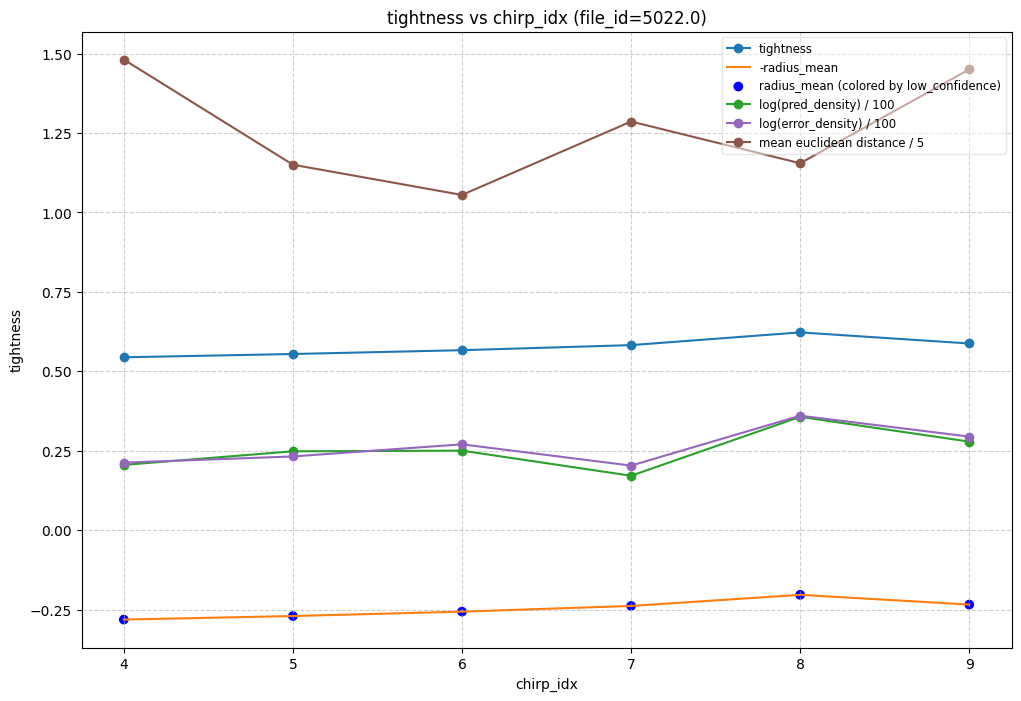

<Axes: title={'center': 'tightness vs chirp_idx (file_id=5022.0)'}, xlabel='chirp_idx', ylabel='tightness'>

In [30]:
import math
def plot_tightness_by_file(file_id, df=df_tightness, ax=None, figsize=(12, 8), show=True, save_filename=None):
    """
    Plot tightness vs chirp_idx for a given file_id using the existing `df_tightness`.
    Returns the matplotlib Axes instance.
    """
    sel = df[df["file_id"] == file_id].copy()
    if sel.empty:
        raise ValueError(f"No rows found for file_id={file_id}")

    sel = sel.sort_values("chirp_idx")
    x = sel["chirp_idx"]
    # if chirp_idx are whole numbers, cast to int for nicer x ticks
    if np.allclose(x % 1, 0):
        x = x.astype(int)
    # y = sel["tightness"]

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    ax.plot(x, sel["tightness"], marker="o", linestyle="-", color="C0")
    # Color points based on the value of sel["low_confidence"]
    colors = sel["low_confidence"].map({True: "red", False: "blue"})
    ax.plot(x, sel["radius_mean"] / -2, marker="", linestyle="-", color="C1")
    ax.scatter(x, sel["radius_mean"] / -2, c=colors, marker="o", label="radius_mean (colored by low_confidence)")
    ax.plot(x, np.log(sel["density"]) / 100, marker="o", linestyle="-", color="C2")
    # ax.plot(x, sel["average_error_per_point"], marker="o", linestyle="-", color="C3")
    ax.plot(x, np.log(sel["error_density"]) / 100, marker="o", linestyle="-", color="C4")
    ax.plot(x, sel["euclidean_distance"] / 5, marker="o", linestyle="-", color="C5")
    ax.set_xlabel("chirp_idx")
    ax.set_ylabel("tightness")

    # ensure x-axis ticks are integer indices (avoid fractional chirp_idx labels)
    x_min = int(np.floor(x.min()))
    x_max = int(np.ceil(x.max()))
    if x_max < x_min:
        x_min, x_max = x_max, x_min
    # limit number of ticks to avoid overcrowding
    if x_max - x_min <= 20:
        ticks = np.arange(x_min, x_max + 1)
    else:
        step = max(1, (x_max - x_min) // 20)
        ticks = np.arange(x_min, x_max + 1, step)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(int(t)) for t in ticks])

    ax.set_title(f"tightness vs chirp_idx (file_id={file_id})")
    ax.grid(True, linestyle="--", alpha=0.6)
    # ax.set_ylim(-1,0.1)

    # label the three plotted series (they were plotted above in order) and show legend
    labels = ["tightness", "-radius_mean", "log(pred_density) / 100", "log(error_density) / 100", "mean euclidean distance / 5"]
    for line, lbl in zip(ax.lines[-len(labels):], labels):
        line.set_label(lbl)
    ax.legend(fontsize="small", framealpha=0.5)

    if show:
        plt.show()

    if save_filename:
        fig_filename = f"{save_filename}.png"
        ax.figure.savefig(fig_filename)
        # print(f"Saved figure to {fig_filename}")
        plt.close()
    return ax

# Example:
plot_tightness_by_file(sample_file_id)

In [31]:
from tqdm import tqdm

test_range = range(4951, 5187)
save_folder = "../../bats_transformer/plots/july_daytime_new_mask_11_5"
if not os.path.exists(save_folder):
    os.mkdir(save_folder)
for fid in tqdm(test_range):
    try:
        plot_tightness_by_file(fid, show=False, save_filename=f"{save_folder}/cluster_plot_{int(fid)}")
    except ValueError as e:
        print(e)

100%|██████████| 236/236 [00:22<00:00, 10.46it/s]


In [ ]:
def find_tightness_drops(
    file_id,
    df=df_tightness,
    window=2,
    method="relative",
    rel_threshold=0.5,
    z_thresh=2.0,
    min_abs_drop=None,
    min_neighbors=1,
    return_type="chirp_idx",
):
    """
    Find chirp_idx within a file where tightness shows a significant decrease
    compared to surrounding chirp_idx values.

    Parameters
    - file_id: value in df['file_id'] to select rows for.
    - df: dataframe with columns ['file_id','chirp_idx','tightness'] (defaults to df_tightness).
    - window: number of neighbors before and after to consider (int).
    - method: one of
        * 'relative'   -> (local_mean - t) / (local_mean) >= rel_threshold
        * 'zscore'     -> (local_mean - t) / local_std >= z_thresh
        * 'absolute'   -> (local_mean - t) >= min_abs_drop
    - rel_threshold: fraction threshold for 'relative' method (default 0.5).
    - z_thresh: threshold in sigma for 'zscore' method (default 2.0).
    - min_abs_drop: minimum absolute drop used by 'absolute' method (if None, must be provided)
    - min_neighbors: minimum number of neighbor points required to evaluate (default 1).
    - return_type: 'chirp_idx' (list), 'df' (rows with diagnostics), or 'indices' (original df indices).

    Returns
    - depending on return_type
    """
    sel = df[df["file_id"] == file_id].copy()
    if sel.empty:
        raise ValueError(f"No rows found for file_id={file_id}")

    # keep original dataframe index so we can return indices if requested
    sel = sel.sort_values("chirp_idx").reset_index().rename(columns={"index": "orig_index"})
    t = sel["tightness"].astype(float).values
    n = len(t)
    eps = 1e-12

    results = []
    for i in range(n):
        # neighbor window: exclude current i
        lo = max(0, i - window)
        hi = min(n, i + window + 1)
        neighbor_idx = list(range(lo, i)) + list(range(i + 1, hi))
        if len(neighbor_idx) < min_neighbors:
            results.append((i, False, np.nan, np.nan, np.nan))
            continue

        neigh_vals = t[neighbor_idx]
        local_mean = float(np.nanmean(neigh_vals))
        local_med = float(np.nanmedian(neigh_vals))
        local_std = float(np.nanstd(neigh_vals, ddof=0))

        drop_amount = local_mean - t[i]
        drop_fraction = drop_amount / (local_mean + eps)
        drop_z = (local_mean - t[i]) / (local_std + eps)

        is_drop = False
        if method == "relative":
            is_drop = (drop_fraction >= rel_threshold)
        elif method == "zscore":
            is_drop = (drop_z >= z_thresh)
        elif method == "absolute":
            if min_abs_drop is None:
                raise ValueError("min_abs_drop must be provided for method='absolute'")
            is_drop = (drop_amount >= min_abs_drop)
        else:
            raise ValueError("method must be one of: 'relative', 'zscore', 'absolute'")

        results.append((i, bool(is_drop), drop_amount, drop_fraction, drop_z))

    res_df = pd.DataFrame(
        results, columns=["pos", "is_drop", "drop_amount", "drop_fraction", "drop_z"]
    )
    # attach chirp_idx and original index and tightness
    res_df["chirp_idx"] = sel["chirp_idx"].values
    res_df["tightness"] = sel["tightness"].values
    res_df["orig_index"] = sel["orig_index"].values

    if return_type == "df":
        return res_df.loc[res_df["is_drop"]].reset_index(drop=True)
    elif return_type == "chirp_idx":
        return res_df.loc[res_df["is_drop"], "chirp_idx"].tolist()
    elif return_type == "indices":
        return res_df.loc[res_df["is_drop"], "orig_index"].tolist()
    else:
        raise ValueError("return_type must be one of: 'df', 'chirp_idx', 'indices'")

# Example usage:
drops = find_tightness_drops(sample_file_id, method='relative', rel_threshold=0.02, window=2, return_type='df')
drops

,pos,is_drop,drop_amount,drop_fraction,drop_z,chirp_idx,tightness,orig_index
0,0,True,0.016334,0.029155,2.726522,4.0,0.543932,548
1,5,True,0.014849,0.024656,0.741580,9.0,0.587402,543


In [146]:
def find_tightness_outliers(
    file_id,
    df=df_tightness,
    method="iqr",
    iqr_multiplier=1.5,
    z_thresh=3.0,
    return_type="df",
):
    """
    Identify chirp_idx rows for a given file_id whose 'tightness' is an outlier.

    Parameters
    - file_id: value in df['file_id'] to select rows for.
    - df: dataframe with columns ['file_id','chirp_idx','tightness'] (defaults to df_tightness).
    - method: 'iqr' (default), 'zscore', or 'modified_zscore' (based on MAD).
    - iqr_multiplier: multiplier for IQR rule (only for method='iqr').
    - z_thresh: threshold for zscore / modified zscore (absolute value).
    - return_type: 'df' (returns DataFrame with an 'is_outlier' column),
                   'chirp_idx' (returns list of chirp_idx values flagged),
                   'indices' (returns DataFrame indices).

    Returns
    - depending on return_type
    """
    sel = df[df["file_id"] == file_id].copy()
    if sel.empty:
        raise ValueError(f"No rows found for file_id={file_id}")

    x = sel["tightness"].astype(float)

    if method == "iqr":
        q1 = np.nanpercentile(x, 25)
        q3 = np.nanpercentile(x, 75)
        iqr = q3 - q1
        lower = q1 - iqr_multiplier * iqr
        upper = q3 + iqr_multiplier * iqr
        is_outlier = (x < lower) | (x > upper)
    elif method == "zscore":
        mu = np.nanmean(x)
        sigma = np.nanstd(x, ddof=0)
        if sigma == 0:
            is_outlier = np.zeros_like(x, dtype=bool)
        else:
            z = (x - mu) / sigma
            is_outlier = np.abs(z) > z_thresh
    elif method == "modified_zscore":
        med = np.nanmedian(x)
        mad = np.nanmedian(np.abs(x - med))
        if mad == 0:
            is_outlier = np.zeros_like(x, dtype=bool)
        else:
            mod_z = 0.6745 * (x - med) / mad
            is_outlier = np.abs(mod_z) > z_thresh
    else:
        raise ValueError("method must be one of: 'iqr', 'zscore', 'modified_zscore'")

    sel["is_outlier"] = is_outlier.values

    if return_type == "df":
        return sel
    elif return_type == "chirp_idx":
        return sel.loc[sel["is_outlier"], "chirp_idx"].tolist()
    elif return_type == "indices":
        return sel.index[sel["is_outlier"]].tolist()
    else:
        raise ValueError("return_type must be one of: 'df', 'chirp_idx', 'indices'")
    
# Example:
outliers = find_tightness_outliers(sample_file_id, method="iqr", return_type="df")
outliers

,id,file_id,chirp_idx,tightness,radius_mean,density,average_error_per_point,error_density,euclidean_distance,is_outlier
543,543,5022.0,9.0,0.587402,0.468757,1.238306e+12,1.067363,6.049859e+12,7.249777,False
544,544,5022.0,8.0,0.622275,0.407466,3.053199e+15,0.835733,4.321773e+15,5.773142,False
545,545,5022.0,7.0,0.582228,0.477433,2.689509e+07,0.896588,6.565930e+08,6.430119,False
546,546,5022.0,6.0,0.566257,0.513273,7.266891e+10,0.662095,5.311453e+11,5.274557,False
547,547,5022.0,5.0,0.554275,0.540845,5.897564e+10,0.797981,1.172436e+10,5.750409,False
548,548,5022.0,4.0,0.543932,0.563238,8.146174e+08,1.003605,1.676398e+09,7.404686,False
